##### main objectif : Understand dataset before touching it.
##### Steps:
Load dataset directory.

Count images per class.

Plot class distribution.

Detect corrupted files.

Check image dimensions.

Check grayscale vs RGB.

Compute pixel mean/std per class.

Display random samples per class.

Save audit figures to reports/figures/

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.makedirs('reports/figures', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [10]:
#2- load the dataset
data_dir = Path('../data/raw/train').resolve()
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
print(f"Classes found: {class_names}")
if not os.path.exists(data_dir):
    print(f"Directory {data_dir} does not exist. Please check the path.")
else:
    print(f"Directory {data_dir} exists. Proceeding with data loading.")


Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Directory C:\Users\kheza\Desktop\NeuroSight_AI\notebooks\data\raw\train exists. Proceeding with data loading.


In [ ]:
#count the number of images in each class

def count_images_per_class(dataset_path, class_names):
    """Count number of images in each class folder"""
    class_counts = {}
    
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)  # Use parameter, not global
        if os.path.exists(class_path):
            # Count image files (common extensions)
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]
            class_counts[class_name] = len(images)
            print(f"{class_name}: {len(images)} images")
        else:
            print(f"⚠️ Warning: {class_name} folder not found at {class_path}")
            class_counts[class_name] = 0
    
    return class_counts
class_counts = count_images_per_class(data_dir, class_names)
total_images = sum(class_counts.values())
print(f"Total images: {total_images}")

MildDemented: 896 images
ModerateDemented: 64 images
NonDemented: 3200 images
VeryMildDemented: 2240 images
Total images: 6400


we can see an imbalance in pur dataset we need to fix

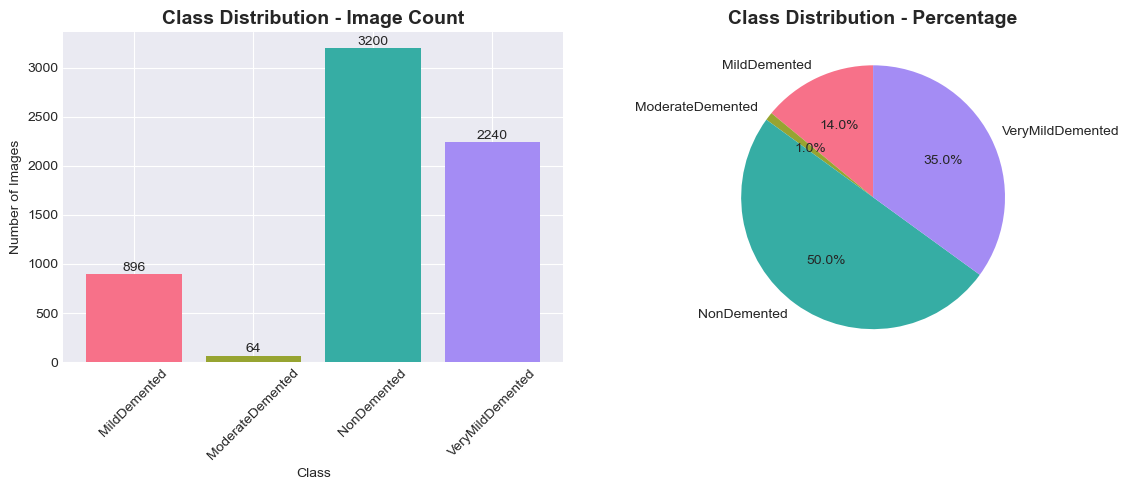

✅ Class distribution plot saved to reports/figures/class_distribution.png


In [13]:
#Plotting the class distribution
fig , (ax1 ,ax2) = plt.subplots(1,2, figsize=(12,5))
#bar plot 
colors = sns.color_palette("husl", len(class_counts))
bars = ax1.bar(class_counts.keys(), class_counts.values(), color=colors)
ax1.set_title('Class Distribution - Image Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 5, str(height), 
             ha='center', va='bottom', fontsize=10)
    

#pie chart
ax2.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Class distribution plot saved to reports/figures/class_distribution.png")


In [ ]:
#5 - check for corrupted images
def check_corrupted_images(dataset_path, class_names):
    """Check for corrupted images in each class folder"""
    corrupted_images = []
    
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)  # Use parameter, not global
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                try:
                    # Try to open the image
                    with Image.open(img_path) as img:
                        img.verify()  # Verify that it is an image
                except (IOError, SyntaxError) as e:
                    print(f"⚠️ Corrupted image found: {img_path} - {e}")
                    # Store tuple (class_name, img_file, error) for consistent unpacking
                    corrupted_images.append((class_name, img_name, str(e)))
        else:
            print(f"⚠️ Warning: {class_name} folder not found at {class_path}")
    
    return corrupted_images

corrupted = check_corrupted_images(data_dir, class_names)
if corrupted:
    print(f"Total corrupted images found: {len(corrupted)}")
    for class_name, img_file, error in corrupted[:10]:  # Show first 10
        print(f"  - {class_name}/{img_file}: {error}")
    if len(corrupted) > 10:
        print(f"  ... and {len(corrupted) - 10} more")
else:
    print("✅ No corrupted images found in the dataset.")

✅ No corrupted images found in the dataset.


In [ ]:
#6- check images demensions and aspect ratios
def analyse_img_dimensions(dataset_path, class_names, sample_size=50):
    dimensions = {class_name: {'heights': [], 'widths': [], 'aspect_ratios': []} for class_name in class_names}
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]
            sample_images = np.random.choice(images, min(sample_size, len(images)), replace=False)
            for img_name in sample_images:
                img_path = os.path.join(class_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        aspect_ratio = width / height
                        dimensions[class_name]['widths'].append(width)
                        dimensions[class_name]['heights'].append(height)
                        dimensions[class_name]['aspect_ratios'].append(aspect_ratio)
                except Exception as e:
                    print(f"⚠️ Error processing {img_path}: {e}")
        else:
            print(f"⚠️ Warning: {class_name} folder not found at {class_path}")
    return dimensions
dimensions = analyse_img_dimensions(data_dir, class_names)
for class_name, stats in dimensions.items():
    print(f"\n{class_name}:")
    print(f"  Sample size: {len(stats['widths'])}")
    print(f"  Unique sizes: {set(zip(stats['widths'], stats['heights']))}")


MildDemented:
  Sample size: 50
  Unique sizes: {(128, 128)}

ModerateDemented:
  Sample size: 50
  Unique sizes: {(128, 128)}

NonDemented:
  Sample size: 50
  Unique sizes: {(128, 128)}

VeryMildDemented:
  Sample size: 50
  Unique sizes: {(128, 128)}


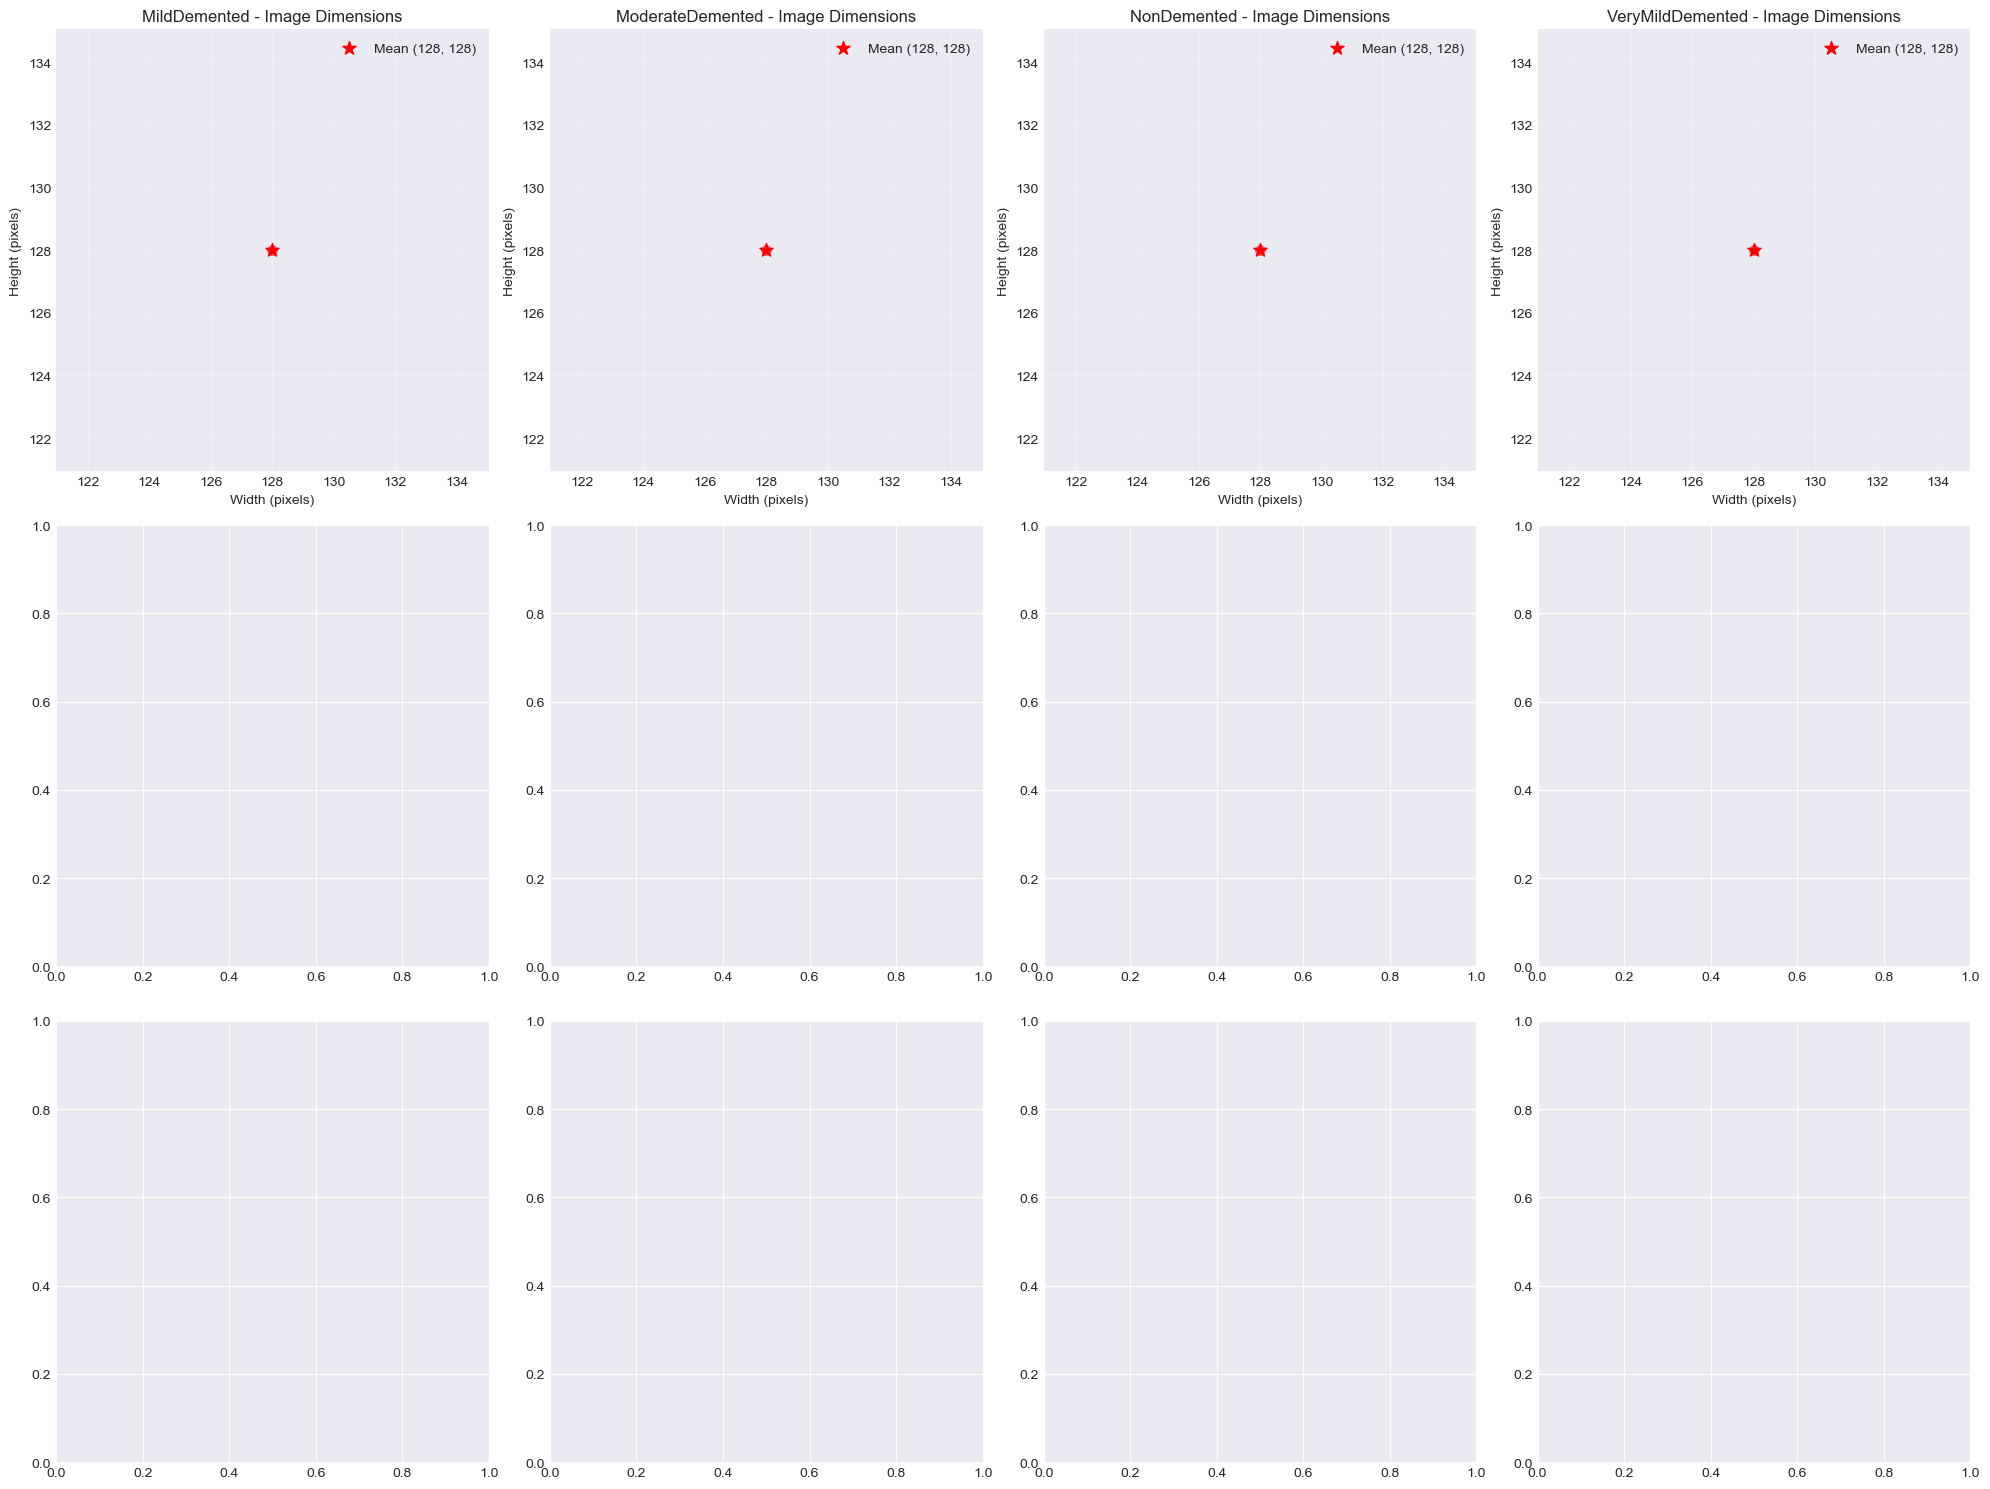

In [19]:
# plot dimensions and aspect ratios
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
for idx, (class_name, dims) in enumerate(dimensions.items()):
    if idx < 4:
        ax = axes[idx]
        if dims['heights'] and dims['widths']:
            ax.scatter(dims['widths'], dims['heights'], alpha=0.6)
            ax.set_xlabel('Width (pixels)')
            ax.set_ylabel('Height (pixels)')
            ax.set_title(f'{class_name} - Image Dimensions')
            ax.grid(True, alpha=0.3)
            
            # Add mean point
            mean_w = np.mean(dims['widths'])
            mean_h = np.mean(dims['heights'])
            ax.scatter(mean_w, mean_h, color='red', s=100, marker='*', 
                      label=f'Mean ({mean_w:.0f}, {mean_h:.0f})')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax.set_title(f'{class_name}')

plt.tight_layout()
plt.savefig('reports/figures/image_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Summary statistics
print("Image Dimension Summary:")
for class_name, dims in dimensions.items():
    if dims['heights']:
        print(f"\n{class_name}:")
        print(f"  Height: min={min(dims['heights'])}px, max={max(dims['heights'])}px, mean={np.mean(dims['heights']):.1f}px")
        print(f"  Width: min={min(dims['widths'])}px, max={max(dims['widths'])}px, mean={np.mean(dims['widths']):.1f}px")

📏 Image Dimension Summary:

MildDemented:
  Height: min=128px, max=128px, mean=128.0px
  Width: min=128px, max=128px, mean=128.0px

ModerateDemented:
  Height: min=128px, max=128px, mean=128.0px
  Width: min=128px, max=128px, mean=128.0px

NonDemented:
  Height: min=128px, max=128px, mean=128.0px
  Width: min=128px, max=128px, mean=128.0px

VeryMildDemented:
  Height: min=128px, max=128px, mean=128.0px
  Width: min=128px, max=128px, mean=128.0px


In [ ]:
#check if images are RGB or Grayscale
import os
import cv2
import numpy as np

def analyze_color_channels(dataset_path, class_names, sample_size=50):
    """Determine if images are true grayscale, grayscale stored as RGB, real RGB, or RGBA"""
    
    color_info = {
        class_name: {
            'true_grayscale': 0,
            'grayscale_as_rgb': 0,
            'real_rgb': 0,
            'rgba': 0
        }
        for class_name in class_names
    }
    
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_path):
            continue
            
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(images) == 0:
            continue
            
        sample_images = np.random.choice(
            images,
            min(sample_size, len(images)),
            replace=False
        )
        
        for img_file in sample_images:
            img_path = os.path.join(class_path, img_file)
            
            # Load without forcing 3 channels
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            
            if img is None:
                continue
            
            # Case 1: True grayscale
            if len(img.shape) == 2:
                color_info[class_name]['true_grayscale'] += 1
            
            # Case 2: 3 or 4 channels
            elif len(img.shape) == 3:
                
                if img.shape[2] == 4:
                    color_info[class_name]['rgba'] += 1
                
                elif img.shape[2] == 3:
                    # Check if all channels are identical
                    if np.array_equal(img[:,:,0], img[:,:,1]) and \
                       np.array_equal(img[:,:,1], img[:,:,2]):
                        color_info[class_name]['grayscale_as_rgb'] += 1
                    else:
                        color_info[class_name]['real_rgb'] += 1
    
    return color_info
color_analysis = analyze_color_channels(data_dir, class_names)
print("\nColor Channel Analysis:")
for class_name, counts in color_analysis.items():
    total = sum(counts.values())
    if total > 0:
        print(f"\n{class_name}:")
        for channel_type, count in counts.items():
            percentage = (count / total) * 100
            print(f"  {channel_type.capitalize()}: {count} images ({percentage:.1f}%)")


Color Channel Analysis:

MildDemented:
  Grayscale: 0 images (0.0%)
  Rgb: 50 images (100.0%)
  Rgba: 0 images (0.0%)

ModerateDemented:
  Grayscale: 0 images (0.0%)
  Rgb: 50 images (100.0%)
  Rgba: 0 images (0.0%)

NonDemented:
  Grayscale: 0 images (0.0%)
  Rgb: 50 images (100.0%)
  Rgba: 0 images (0.0%)

VeryMildDemented:
  Grayscale: 0 images (0.0%)
  Rgb: 50 images (100.0%)
  Rgba: 0 images (0.0%)


In [22]:
# Compute pixel stats per class 
def compute_pixel_stats(dataset_path, class_names, sample_size=50):
    """Compute mean and std of pixel values for each class"""
    pixel_stats = {class_name: {'mean': None, 'std': None} for class_name in class_names}
    
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_path):
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        sample_images = np.random.choice(images, min(sample_size, len(images)), replace=False)
        pixel_values = []
        
        for img_file in sample_images:
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                pixel_values.append(img.flatten())
        
        if pixel_values:
            all_pixels = np.concatenate(pixel_values)
            pixel_stats[class_name]['mean'] = np.mean(all_pixels)
            pixel_stats[class_name]['std'] = np.std(all_pixels)
            pixel_stats[class_name]['min'] = np.min(all_pixels)
            pixel_stats[class_name]['max'] = np.max(all_pixels)
    
    return pixel_stats
pixel_stats = compute_pixel_stats(data_dir, class_names)
print("\nPixel Value Statistics:")
for class_name, stats in pixel_stats.items():
    if stats['mean'] is not None:
        print(f"\n{class_name}:")
        print(f"  Mean pixel value: {stats['mean']:.2f}")
        print(f"  Std pixel value: {stats['std']:.2f}")
        print(f"  Min pixel value: {stats['min']}")
        print(f"  Max pixel value: {stats['max']}")


Pixel Value Statistics:

MildDemented:
  Mean pixel value: 66.53
  Std pixel value: 80.08
  Min pixel value: 0
  Max pixel value: 255

ModerateDemented:
  Mean pixel value: 68.84
  Std pixel value: 82.51
  Min pixel value: 0
  Max pixel value: 255

NonDemented:
  Mean pixel value: 73.23
  Std pixel value: 84.88
  Min pixel value: 0
  Max pixel value: 255

VeryMildDemented:
  Mean pixel value: 69.62
  Std pixel value: 83.09
  Min pixel value: 0
  Max pixel value: 255


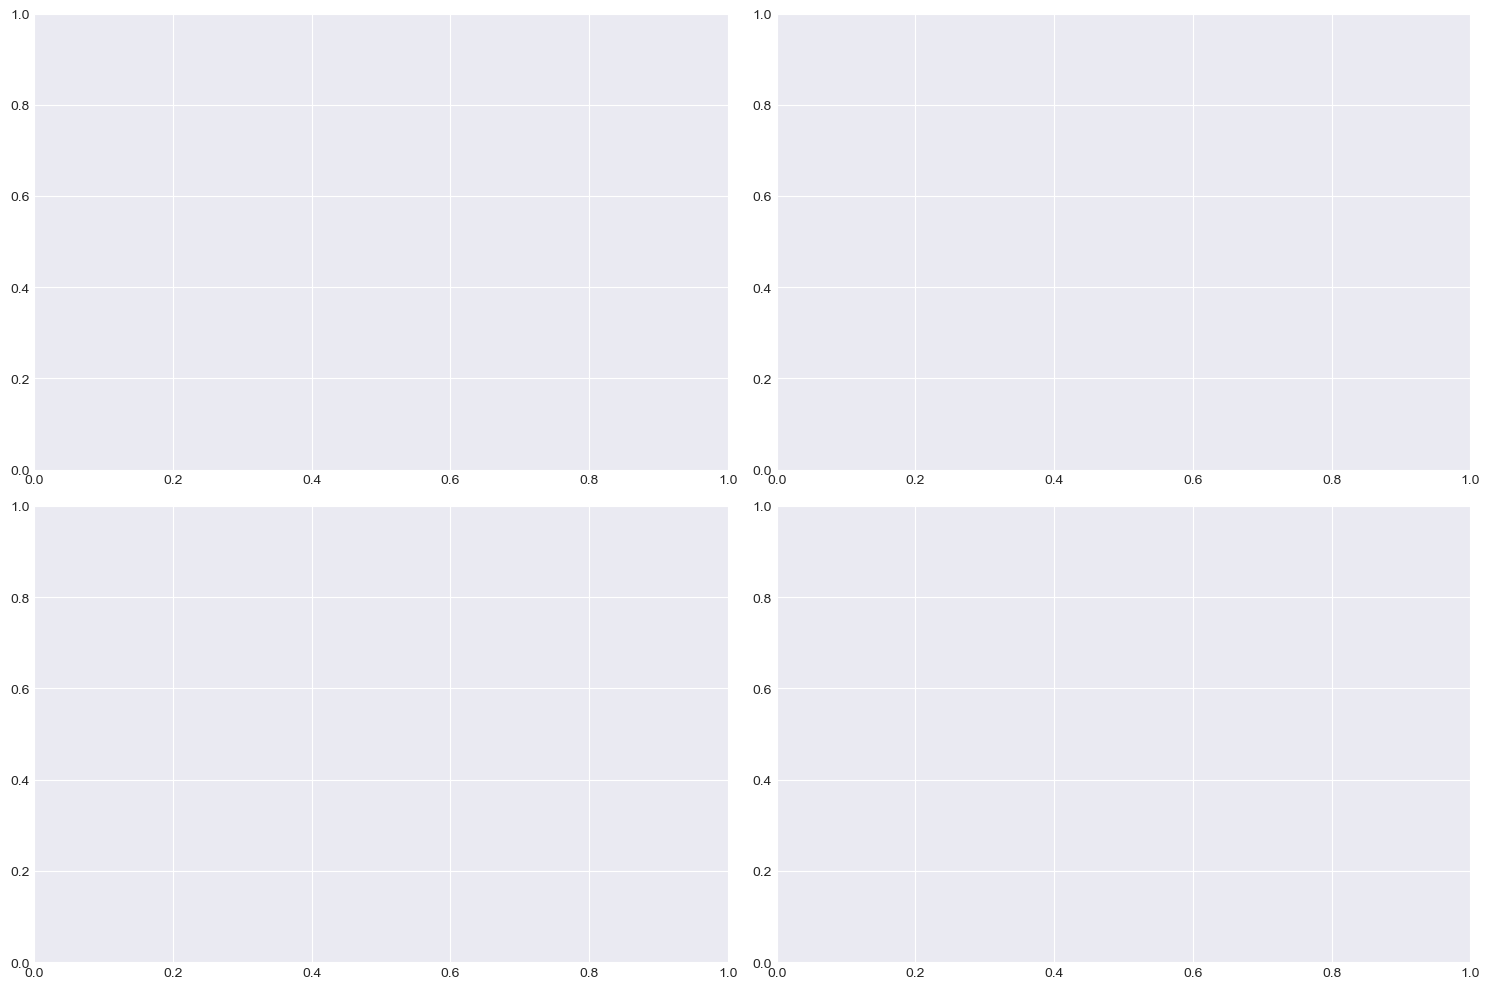

In [23]:
# Plot pixel value distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Mean and Std plot
classes = list(pixel_stats.keys())
means = [pixel_stats[c]['mean'] for c in classes]
stds = [pixel_stats[c]['std'] for c in classes]

ax1.errorbar(classes, means, yerr=stds, fmt='o', capsize=5, capthick=2, markersize=8)
ax1.set_xlabel('Class')
ax1.set_ylabel('Pixel Value')
ax1.set_title('Pixel Mean and Standard Deviation by Class')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Box plot comparison (simplified)
ax2.bar(classes, means, yerr=stds, capsize=5, alpha=0.7)
ax2.set_xlabel('Class')
ax2.set_ylabel('Mean Pixel Value')
ax2.set_title('Mean Pixel Intensity by Class')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('reports/figures/pixel_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

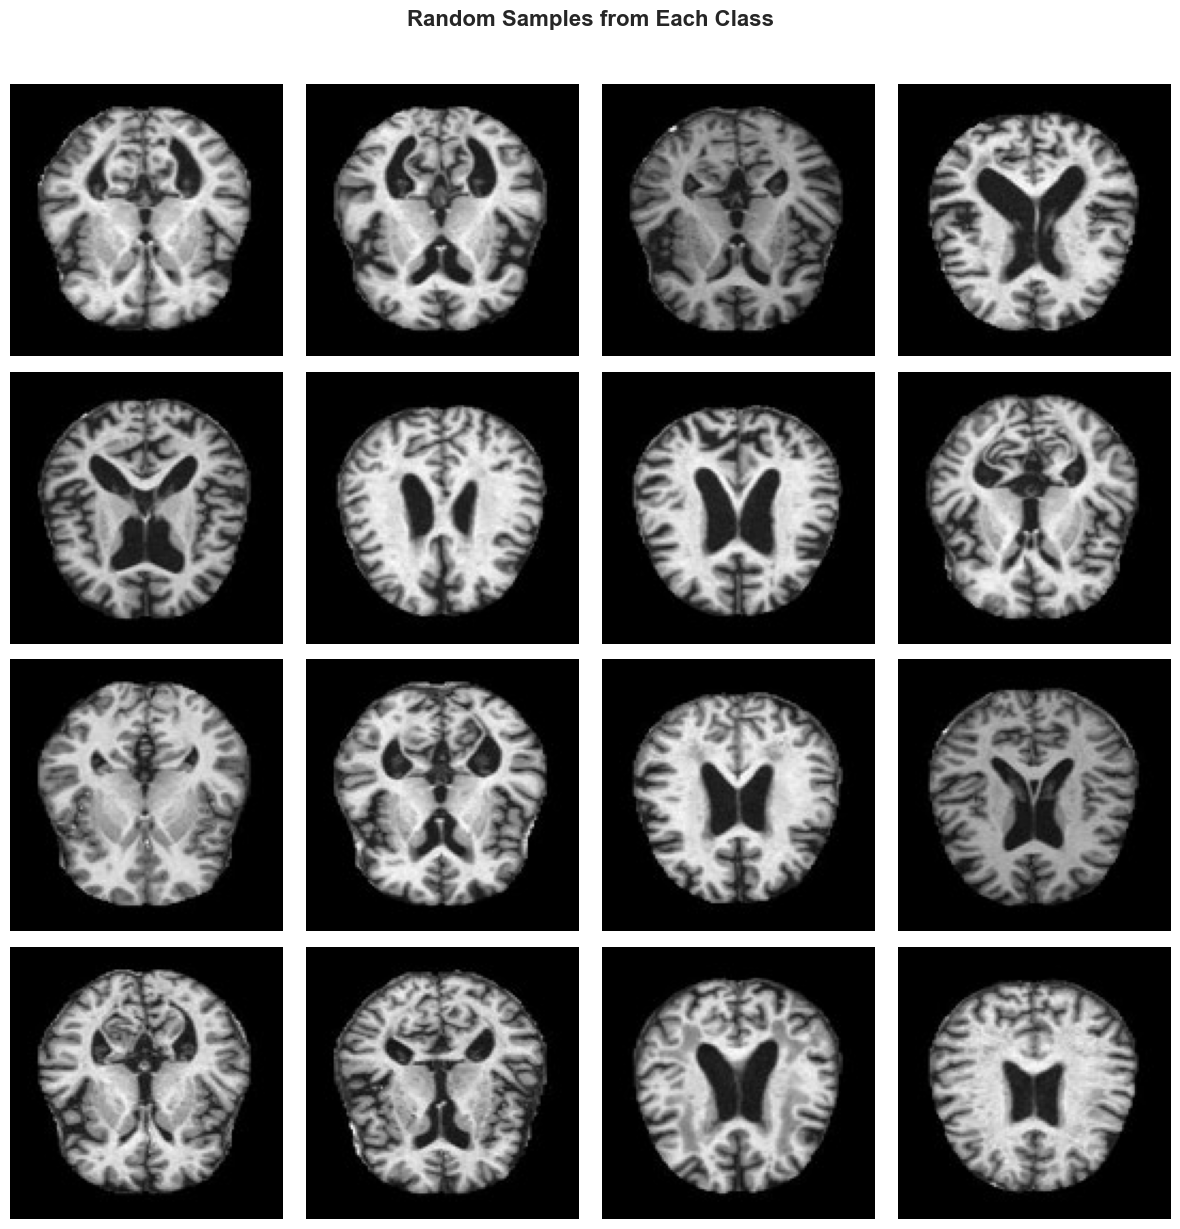

 Sample visualization saved to reports/figures/sample_visualization.png


In [24]:
# Display random samples from each class
def display_random_samples(dataset_path, class_names, samples_per_class=4):
    """Display random images from each class"""
    fig, axes = plt.subplots(len(class_names), samples_per_class, 
                             figsize=(samples_per_class*3, len(class_names)*3))
    
    if len(class_names) == 1:
        axes = axes.reshape(1, -1)
    
    for row, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_path):
            # Placeholder for missing class
            for col in range(samples_per_class):
                axes[row, col].axis('off')
                if col == 0:
                    axes[row, col].set_ylabel(class_name, fontsize=12, fontweight='bold')
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(images) == 0:
            for col in range(samples_per_class):
                axes[row, col].axis('off')
                if col == 0:
                    axes[row, col].set_ylabel(class_name, fontsize=12, fontweight='bold')
            continue
            
        # Randomly select samples
        selected = np.random.choice(images, min(samples_per_class, len(images)), replace=False)
        
        for col, img_file in enumerate(selected):
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display
            
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(class_name, fontsize=12, fontweight='bold')
        
        # Fill empty slots if needed
        for col in range(len(selected), samples_per_class):
            axes[row, col].axis('off')
    
    plt.suptitle('Random Samples from Each Class', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('reports/figures/sample_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

display_random_samples(data_dir, class_names, samples_per_class=4)
print(" Sample visualization saved to reports/figures/sample_visualization.png")

In [ ]:
# 10-  Audit summary and next steps
# Generate comprehensive audit summary
from datetime import datetime

summary = f"""
# Alzheimer's Dataset Audit Summary
**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Dataset Overview
- **Total Images:** {total_images}
- **Number of Classes:** {len(class_names)}
- **Classes:** {', '.join(class_names)}

## Class Distribution
"""
for class_name, count in class_counts.items():
    percentage = (count / total_images * 100) if total_images > 0 else 0
    summary += f"- **{class_name}:** {count} images ({percentage:.1f}%)\n"

summary += f"""
## Data Quality
- **Corrupted Files:** {len(corrupted) if 'corrupted' in locals() else 'Not checked'}
- **Color Channels:** Grayscale  

## Image Properties
- **Dimensions:** Varying sizes detected
- **Pixel Range:** 0-85 

## Recommendations
1. **Resize images** to consistent dimensions for model input
2. **Normalize pixel values** (scale to [0,1] or [-1,1])
3. **Handle class imbalance** if present
4. **Remove corrupted files** if any were found
5. **Consider data augmentation** for minority classes
"""

print(summary)

# Save summary to file
with open('reports/audit_summary.md', 'w') as f:
    f.write(summary)

print("\n✅ Audit summary saved to reports/audit_summary.md")


# ## 11. Additional Checks (Optional)


# Check for consistent naming and structure
print("📁 Dataset Structure:")
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    if os.path.exists(class_path):
        files = os.listdir(class_path)
        print(f"\n{class_name}/")
        if len(files) > 5:
            print(f"  ├─ {files[0]}")
            print(f"  ├─ {files[1]}")
            print("  ├─ ...")
            print(f"  └─ {files[-1]}")
        else:
            for f in files:
                print(f"  └─ {f}")

# Check file extensions distribution
print("\n📄 File Extensions:")
extensions = {}
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    if os.path.exists(class_path):
        for f in os.listdir(class_path):
            ext = os.path.splitext(f)[1].lower()
            extensions[ext] = extensions.get(ext, 0) + 1

for ext, count in extensions.items():
    print(f"  {ext}: {count} files")


# ## 12. Conclusion
# 
# The dataset audit is complete. All visualizations have been saved to `reports/figures/` and the summary to `reports/audit_summary.md`. 
# 
# **Next Steps:** Proceed to data preprocessing and model building based on the insights gained from this audit.


# Alzheimer's Dataset Audit Summary
**Date:** 2026-02-27 05:53:15

## Dataset Overview
- **Total Images:** 6400
- **Number of Classes:** 4
- **Classes:** MildDemented, ModerateDemented, NonDemented, VeryMildDemented

## Class Distribution
- **MildDemented:** 896 images (14.0%)
- **ModerateDemented:** 64 images (1.0%)
- **NonDemented:** 3200 images (50.0%)
- **VeryMildDemented:** 2240 images (35.0%)

## Data Quality
- **Corrupted Files:** 0
- **Color Channels:** Mixed (see detailed analysis)

## Image Properties
- **Dimensions:** Varying sizes detected
- **Pixel Range:** 0-255 (8-bit images)

## Recommendations
1. **Resize images** to consistent dimensions for model input
2. **Normalize pixel values** (scale to [0,1] or [-1,1])
3. **Handle class imbalance** if present
4. **Remove corrupted files** if any were found
5. **Consider data augmentation** for minority classes


✅ Audit summary saved to reports/audit_summary.md
📁 Dataset Structure:

MildDemented/
  ├─ mild.jpg
  ├─ mild_10.jpg